# Approches semi-supervisées en traitement d'images

Préparez les images (redimensionnement, normalisation) et utilisez un modèle pré-entraîné (ex : ResNet) pour extraire des embeddings visuels.



## Extraction des features

L'extraction des features peut être réalisée en utilisant un modéle de vision déjà entrainé.

Les modèles les plus courants sont disponibles sur les principales bibliothèques de machine learning comme:
- https://docs.pytorch.org/vision/0.8/models.html
- https://keras.io/keras_hub/api/base_classes/image_classifier/#imageclassifier-class
- https://huggingface.co/models?pipeline_tag=image-classification&library=transformers&sort=likes

Pour la suite de cette présentation la bibliothèque de Huggingface sera utilisée comme exemple.

Le concepte est de récupérer le modèle et d'enlever les dernières couches de classification pour mettre des couches ou des traitements personnalisés.

Une démonstration va être réalisée avec l'image suivante:



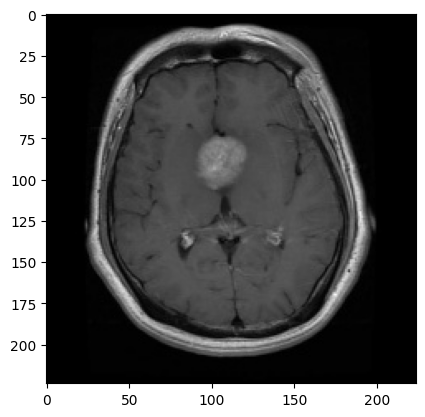

In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt


# Image de test
current_dir = os.getcwd()
image_test = current_dir + "/../data/preprocessed/cancer/546ccef0-d10d-4e24-b3dd-660365910236.jpg"
img = cv2.imread(image_test)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()


### format de l'image en entrée

Le format attendu par le modèle est disponible dans la documentation. Il varie d'un modèle à l'autre. Ci dessous, nous avons dans les exemples les formats suivants:
- RGB: 224 * 224
- RGB: 256 * 256
- RGB: 512 * 512

On peut noter que certains pipelines possèdent les fonctions de redimenssionnement et de recadrage. Cela est à connaitre pour chaque modèle.


### Normalisation de l'image

La normalisation des images permet une mise à l'échelle des couleurs conforment aux valeurs qui ont été utilisées pour l'entrainement des modèles. Les valeurs de normalisations sont fournis sont forme de vecteur pour les 3 couleurs (moyenne et ecart type). Par exemple:
- "image_mean": [0.485, 0.456, 0.406], "image_std": [0.229, 0.224, 0.225]
- "image_mean": [0.5, 0.5, 0.5], "image_std": [0.5, 0.5, 0.5]

On peut noter que certains pipelines possèdent les fonctions de normalisation. Cela est à connaitre pour chaque modèle.


### Pooling en sortie

Le pooling correspond à l'opération de transformer les informations en sortie du modèle vers un vecteurs à une dimension qui poura être traité en machine learning. En activant/desactivant l'option pool, il est possible d'avoir toute l'architecture de la sortie ou seulement le vecteur agrégé.


Différentes architectures existent. Par exemple:, 
pour les modèle de type resnet:

Format features: microsoft/resnet-50 :  (1, 2048, 7, 7) -> np.mean(features, axis=(2, 3)) -> (1, 2048, 1, 1)

pour les modèle de type dinov2:

Format features: facebook/dinov2-base : (1, 257, 768) -> features_xd[:, 0, :] -> (1, 768) 



In [2]:
from transformers import AutoImageProcessor, AutoModel
import torch
from PIL import Image
import numpy as np
import pandas as pd
import os

model_name = "microsoft/resnet-50"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

model_config = model.config

print("Configuration du modèle:\n")
print(f"Nom du modèle: {model_config.name_or_path}")
print(f"Type de modèle: {model_config.model_type}")
print("Configuration du preprocesseur:\n")
print("Taille des images en entrée:", processor.size)
print("Auto redimenssionnement:", processor.do_resize)

print("Normalisation: moyenne des couleurs", processor.image_mean)
print("Normalisation: écart type", processor.image_std)
print("Auto normalisation:", processor.do_normalize)




def images_features(image_path, processor, model):
    """ return feature of the image """
    image = Image.open(image_path)
    inputs = processor(images=image, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
        pooled_features = outputs.last_hidden_state.mean(dim=(2,3)).detach().cpu().numpy()
        return pooled_features[0]
    return []



result = images_features(image_test, processor, model)
print("\nResultat avec une image de test, nb features", result.shape[0], result)


# Load the dataframe with image list and basic informations
# Adapte the data path with your configuration
data_path = "../data"
df_images_filepath = os.path.join(data_path, "images.parquet")
df_images = pd.read_parquet(df_images_filepath)

# Add feature column
feature_column = [f"f_{i}" for i in range(len(result))]
df_images[feature_column] = 0.0









The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/318 [00:00<?, ?it/s]

ResNetModel LOAD REPORT from: microsoft/resnet-50
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.1.weight | UNEXPECTED |  | 
classifier.1.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Configuration du modèle:

Nom du modèle: microsoft/resnet-50
Type de modèle: resnet
Configuration du preprocesseur:

Taille des images en entrée: {'shortest_edge': 224}
Auto redimenssionnement: True
Normalisation: moyenne des couleurs [0.485, 0.456, 0.406]
Normalisation: écart type [0.229, 0.224, 0.225]
Auto normalisation: True

Resultat avec une image de test, nb features 2048 [0.06542611 0.         0.         ... 0.17579125 0.03670237 0.        ]


/tmp/ipykernel_19769/930621624.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_images[feature_column] = 0.0


In [3]:
import time 

# features extraction and save
start_time = time.time()

for index, row in df_images.iterrows():
    image_path = os.path.join("../", row["path"], row["filename"])
    features = images_features(image_path, processor, model)
    df_images.loc[index, feature_column] = features

df_features_filepath = os.path.join(data_path, "images_feature.parquet")
df_images.to_parquet(df_features_filepath, index=False)

end_time = round(time.time() - start_time, 3)
print("time to finish", end_time)
    
display(df_images)
    

time to finish 2749.118


,path,filename,format,width,height,mode,size_bytes,is_grayscale,brightness,contrast,...,f_2038,f_2039,f_2040,f_2041,f_2042,f_2043,f_2044,f_2045,f_2046,f_2047
0,data/avec_labels/cancer,b6a41ca0-aeea-43a8-b629-7c433cf03143.jpg,jpg,512,512,RGB,20159,True,32,37,...,0.005332,0.002420,0.000000,0.040658,0.002660,0.295007,0.049811,0.130986,0.129422,0.000000
1,data/avec_labels/cancer,0f718241-8f63-4b55-81ce-315324b51069.jpg,jpg,512,512,RGB,18113,True,27,36,...,0.007254,0.000000,0.000000,0.001363,0.000000,0.000000,0.000000,0.131745,0.146682,0.001071
2,data/avec_labels/cancer,73352791-6331-48a0-b0d1-045fb31d376c.jpg,jpg,512,512,RGB,23490,True,40,44,...,0.000000,0.051002,0.000000,0.000000,0.000000,0.008049,0.016675,0.070556,0.025744,0.031750
3,data/avec_labels/cancer,d018fae6-42d9-4de3-acbf-6c2637c28482.jpg,jpg,512,512,RGB,23321,True,42,42,...,0.013008,0.013794,0.000000,0.000215,0.008916,0.063021,0.002253,0.128358,0.112788,0.000000
4,data/avec_labels/cancer,cb4e6fda-be13-454b-bbda-f75e184444d5.jpg,jpg,512,512,RGB,24468,True,53,41,...,0.002034,0.012773,0.000000,0.000000,0.009872,0.154682,0.018212,0.187469,0.011837,0.237796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1501,data/sans_label,71334459-58f0-4373-8805-6100e6d9b5ed.jpg,jpg,512,512,RGB,27831,True,104,91,...,0.000000,0.005378,0.000000,0.000000,0.000338,0.000000,0.497949,0.192432,0.019270,0.003347
1502,data/sans_label,b5a05df2-50ea-435b-8946-f4ba1bb1d9ac.jpg,jpg,512,512,RGB,26169,True,64,49,...,0.000000,0.000000,0.000000,0.000000,0.036624,0.005485,0.035494,0.070094,0.056662,0.027113
1503,data/sans_label,b5b311b5-9264-4d34-a9a5-8952ecf727cb.jpg,jpg,512,512,RGB,22737,True,32,38,...,0.001513,0.000000,0.004794,0.000000,0.000000,0.056435,0.063832,0.145722,0.047076,0.000000
1504,data/sans_label,40b1313e-6c50-488f-9066-bfefc7c5b2e1.jpg,jpg,512,512,RGB,14638,True,22,31,...,0.001831,0.162391,0.000000,0.000000,0.002723,0.000000,0.000000,0.000511,0.086267,0.000000


Le temps de traitement pour les 1506 images est de 31 mn sur un poste standard.
